In [28]:
import tskit as ts
import numpy as np
import matplotlib.pyplot as plt

In [29]:
treesequence = ts.load("/Users/ricardorivero/Documents/GitHub/Espalier/TestFiles/Outputs/arg_output_2026-01-14_114649/arg_treesequence.trees")



In [30]:
treesequence.draw_svg(
    size=(1600, 600),
    y_axis=True,
    node_labels=[]
)

ts.set_print_options(max_lines=1000)
print(treesequence.tables.nodes)

╔═══╤══════╤══════════╤══════════╤══════════╤════════╗
║id │flags │population│individual│time      │metadata║
╠═══╪══════╪══════════╪══════════╪══════════╪════════╣
║0  │     1│        -1│        -1│0.00000000│        ║
║1  │     1│        -1│        -1│0.00000000│        ║
║2  │     1│        -1│        -1│0.00000000│        ║
║3  │     1│        -1│        -1│0.00000000│        ║
║4  │     1│        -1│        -1│0.00000000│        ║
║5  │     1│        -1│        -1│0.00000000│        ║
║6  │     1│        -1│        -1│0.00000000│        ║
║7  │     1│        -1│        -1│0.00000000│        ║
║8  │     1│        -1│        -1│0.00000000│        ║
║9  │     1│        -1│        -1│0.00000000│        ║
║10 │     1│        -1│        -1│0.00000000│        ║
║11 │     1│        -1│        -1│0.00000000│        ║
║12 │     1│        -1│        -1│0.00000000│        ║
║13 │     1│        -1│        -1│0.00000000│        ║
║14 │     1│        -1│        -1│0.00000000│        ║
║15 │     

In [33]:
from pathlib import Path
import subprocess
import baltic as bt

trees = '/Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/arg_treesequence.trees'
tips_tree = '/Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/HA-swine_H1_HANA.aln_ARG_local.tre'
out_nex = '/Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/arg_network.newick'

script_path = Path('scripts/tskit_to_extended_newick.py')
if not script_path.exists():
    script_path = Path('tskit_to_extended_newick.py')

cmd = [
    'python', str(script_path),
    '--trees', trees,
    '--output', out_nex,
    '--tips-from-tree', tips_tree,
    '--follow-segment', '-1',  # auto-select backbone segment
    '--collapse-root-edges'
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)

ll = bt.loadNewick("/Users/ricardorivero/Documents/GitHub/Espalier/TestFiles/Outputs/arg_output_2026-01-14_114649/arg_network.newick", absoluteTime=False, verbose=False, sortBranches=False)
print('Objects:', len(ll.Objects))
print('Reticulations:', len([k for k in ll.Objects if isinstance(k, bt.reticulation)]))

for k in ll.Objects:
    if hasattr(k, 'length') and k.length is not None and k.length <= 0:
        k.length = 1e-7

for k in ll.Objects:
    k.traits['re'] = 0

for k in sorted(ll.Objects, key=lambda w: w.height):
    if hasattr(k, 'contribution'):
        for w in ll.traverse_tree(k, include_condition=lambda w: True):
            w.traits['re'] = max([w.traits['re'] + 1, k.contribution.traits['re'] + 1])

def is_reassortment_node(node):
    return hasattr(node, 'contribution')

def get_descendant_tip_names(tree, node):
    tip_names = []
    for descendant in tree.traverse_tree(node, include_condition=lambda w: True):
        if descendant.branchType == 'leaf' and descendant.is_leaf():
            name = descendant.name
            if isinstance(name, str) and name.startswith('_dangling_H'):
                continue
            tip_names.append(name)
    return tip_names

reassortment_info = []
for node in ll.Objects:
    if is_reassortment_node(node):
        height = node.height
        tip_names = get_descendant_tip_names(ll, node)
        reassortment_info.append((node, height, tip_names))

print('Reassortment nodes:', len(reassortment_info))
print('Example:', reassortment_info[:3])


Running: python tskit_to_extended_newick.py --trees /Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/arg_treesequence.trees --output /Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/arg_network.newick --tips-from-tree /Users/ricardorivero/Documents/GitHub/Espalier/FluTest_subsampled_output/arg_output_2026-01-14_172446/HA-swine_H1_HANA.aln_ARG_local.tre --follow-segment -1 --collapse-root-edges
Objects: 185
Reticulations: 19
Reassortment nodes: 19
Example: [(<baltic.baltic.node object at 0x131bf0c00>, 0.07917465069189317, ['234|2022-12-16']), (<baltic.baltic.node object at 0x131bf3b70>, 0.25909334000000006, ['Klyukva|2019-01-01', 'Moskow_Cg8453|2019-01-01', 'Penza_Cg8730|2019-01-01', 'Postoyalyye_Dvory|2019-01-01', '656|2019-07-16', 'Tyumen_Cg8928|2019-01-01', '1186|2019-10-17', '12|2023-01-13', 'Saratov_MG125_Russia_2019|2019-05-01', '42|2023-01-18', '1039|2019-10-04', '701|2019-07

Auto follow_segment=1 (pair coverage [94, 120])


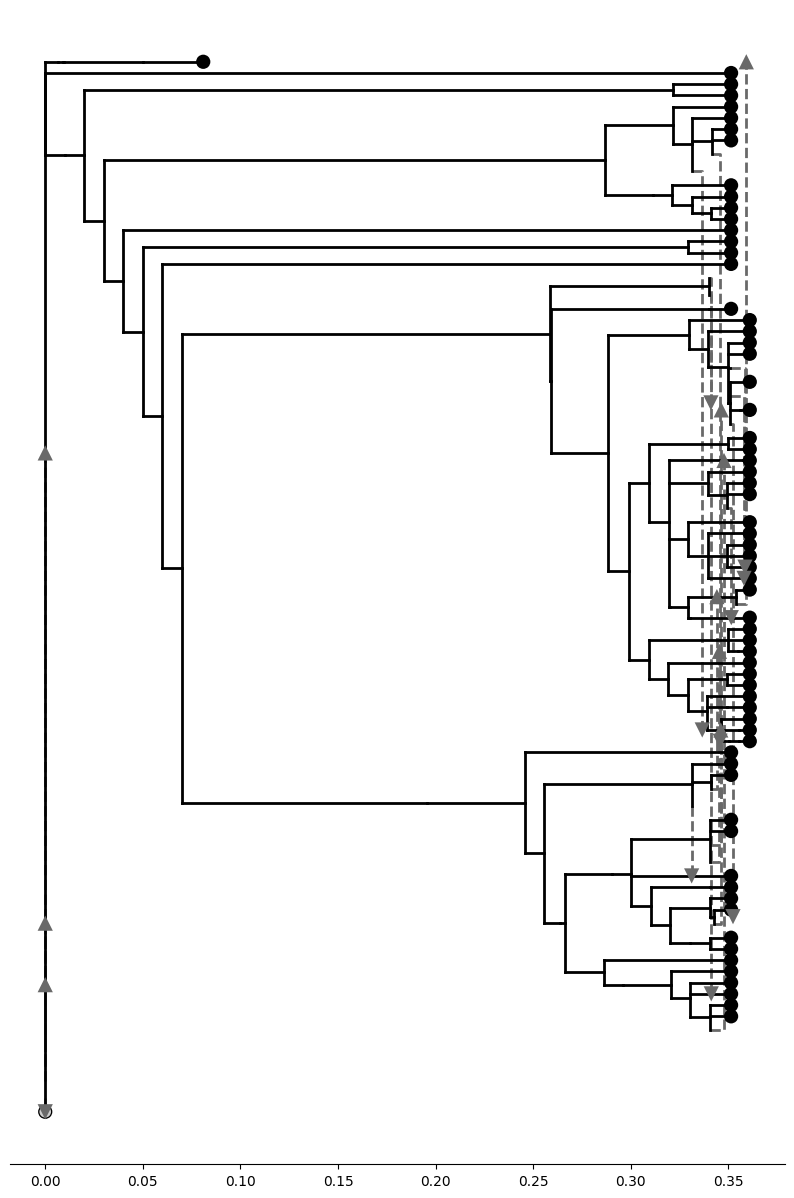

In [34]:
import matplotlib.pyplot as plt
import baltic as bt

# Load the network if not already loaded
restore_original_names = True  # set False if you plan to re-plot without reloading
# ll = bt.loadNewick(out_nex, absoluteTime=False, verbose=False, sortBranches=False)

def is_dangling_tip(node):
    return bool(node.traits.get('dummy', False))

# Preserve original labels and make leaflike names unique for plotting
leaflike = [k for k in ll.Objects if k.is_leaflike()]
used = {}
for k in leaflike:
    # Save original label once
    if 'orig_name' not in k.traits:
        k.traits['orig_name'] = k.name
    base = k.traits['orig_name'] if k.traits.get('orig_name') is not None else 'unnamed'
    count = used.get(base, 0)
    k.name = base if count == 0 else f'{base}_{count}'
    used[base] = count + 1

# Decide x-axis attribute
use_absolute_time = any(getattr(k, 'absoluteTime', None) is not None for k in ll.Objects)
x_attr = (lambda k: k.absoluteTime) if use_absolute_time else (lambda k: k.height)

fig, ax = plt.subplots(figsize=(10, 15), facecolor='w')

# Ensure positive lengths
for node in ll.Objects:
    if hasattr(node, 'length') and node.length is not None and node.length <= 0:
        node.length = 1e-7

# Define reassortment trait
for k in ll.Objects:
    k.traits['re'] = 0

# Traverse branches to identify reassortments and calculate reassortment numbers
for k in sorted(ll.Objects, key=lambda w: w.height):
    if hasattr(k, 'contribution'):
        for w in ll.traverse_tree(k, include_condition=lambda w: True):
            w.traits['re'] = max([w.traits['re'] + 1, k.contribution.traits['re'] + 1])

def is_reassortment_node(node):
    return hasattr(node, 'contribution')

def get_descendant_tip_names(tree, node):
    tip_names = []
    for descendant in tree.traverse_tree(node, include_condition=lambda w: True):
        if descendant.branchType == 'leaf' and descendant.is_leaf():
            if descendant.traits.get('dummy', False):
                continue
            tip_names.append(descendant.traits.get('orig_name', descendant.name))
    return tip_names

# Extract reassortment nodes, their heights, and descendant tip names
reassortment_info = []
for node in ll.Objects:
    if is_reassortment_node(node):
        height = node.height
        tip_names = get_descendant_tip_names(ll, node)
        reassortment_info.append((node, height, tip_names))

# Optional host-based colouring (expects name with pipe-delimited fields)
for k in ll.Objects:
    if k.branchType == 'leaf' and k.is_leaf():
        name_src = k.traits.get('orig_name', k.name)
        if is_dangling_tip(k):
            continue
        parts = name_src.split('|') if isinstance(name_src, str) else []
        if len(parts) > 4:
            k.traits['host'] = parts[4]

tip_colours = {
    'Apodemus_agrarius': '#582851',
    'Homo_sapiens': '#40606d',
    'Microtus_fortis': '#69a257',
    'Niniventer': '#e3d19c',
    'Rattus_norvegicus': '#c4024d'
}

def colour_func(k):
    if k.branchType == 'leaf' and k.is_leaf():
        if is_dangling_tip(k):
            return '#cccccc'
        host = k.traits.get('host')
        if host in tip_colours:
            return tip_colours[host]
    return '#000000'

# Plot the tree (skip reticulation tips for main tree)
target = lambda k: not isinstance(k, bt.reticulation)

def safe_draw_tree(tree, x_attr):
    order = tree.traverse_tree(include_condition=lambda k: k.is_leaflike())
    name_order = {x.name: i for i, x in enumerate(order)}
    skips = [1 if isinstance(x, bt.leaf) else x.width + 1 for x in order]
    for k in tree.Objects:
        k.x = None
        k.y = None
    for k in order:
        k.x = x_attr(k)
        y_idx = name_order[k.name]
        k.y = sum(skips[y_idx:]) - skips[y_idx] / 2.0
    drawn = set(order)
    progressed = True
    while progressed and len(drawn) != len(tree.Objects):
        progressed = False
        for k in filter(lambda w: w not in drawn, tree.getInternal()):
            if len([q.y for q in k.children if q.y is not None]) == len(k.children):
                k.x = x_attr(k)
                k.y = sum([q.y for q in k.children if q.y is not None]) / float(len(k.children))
                drawn.add(k)
                progressed = True
    if len(drawn) != len(tree.Objects):
        print(f'Warning: could not place all nodes (placed {len(drawn)}/{len(tree.Objects)})')

safe_draw_tree(ll, x_attr)

# Plot the tree (skip reticulation tips for main tree)
target = lambda k: not isinstance(k, bt.reticulation)
ll.plotTree(ax, target=target, x_attr=x_attr, y_attr=lambda k: k.y)
ll.plotPoints(ax, x_attr=x_attr, zorder=100, colour=colour_func, outline_size=70*1.5, size=70)

for k in sorted(ll.getBranches(lambda w: w.is_leaflike() and w.is_leaf() == False), key=lambda q: -q.y):
    if isinstance(k, bt.reticulation):
        if getattr(k, 'target', None) is None or k.parent is None:
            continue
        segs = sorted(map(int, k.traits.get('segments', [])))
        if not segs:
            continue
        c = 'dimgrey'
        size = 60
        xp = x_attr(k.parent)
        x = x_attr(k)
        y = k.y
        ax.plot([xp, x, x], [y, y, k.target.y], color=c, lw=2, ls='--', zorder=1)
        marker = '^' if k.target.y > k.y else 'v'
        ax.scatter(x, k.target.y, s=size, marker=marker, facecolor=c, edgecolor='none', zorder=300)
        ax.scatter(x, k.target.y, s=size * 2, marker=marker, facecolor=c, edgecolor='none', zorder=299)

[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
ax.set_yticks([])
ax.set_yticklabels([])
plt.xlabel('')

# Restore original labels for downstream analysis (safe after plotting)
if restore_original_names:
    for k in ll.Objects:
        if 'orig_name' in k.traits:
            k.name = k.traits['orig_name']
plt.show()
